In [1]:
import scanpy as sc
import os
import glob
import pandas as pd
import anndata as ad
from sklearn.metrics import silhouette_score
import seaborn as sns   

/mnt/netapp2/Store_uni/home/ulc/co/mao/SOFTWARE/miniconda3/envs/sc/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/mnt/netapp2/Store_uni/home/ulc/co/mao/SOFTWARE/miniconda3/envs/sc/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/mnt/netapp2/Store_uni/home/ulc/co/mao/SOFTWARE/miniconda3/envs/sc/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/mnt/netapp2/Store_uni/home/ulc/co/mao/SOFTWARE/miniconda3/envs/sc/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.war

In [2]:
neighbors_list   = [15,30,45]
resolution_list  = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0,1.2,1.4,1.6,1.8,2.0]
OUTPUT_H5AD = "/mnt/lustre/scratch/nlsas/home/ulc/co/mao/modelo_prueba_final_fast_convergence/adata/mofa_adata_30f.h5ad"
adata_mofa = ad.read(OUTPUT_H5AD)
# 1. Cargar datos
save_dir = "/mnt/lustre/scratch/nlsas/home/ulc/co/mao/modelo_prueba_final_fast_convergence/leiden_results"
os.makedirs(save_dir, exist_ok=True)

# 2. Bucle optimizado
for k in neighbors_list:
    print(f"\n===== Procesando Vecinos (k={k}) =====")
    
    # A. Calcular vecinos y UMAP UNA SOLA VEZ por cada 'k'
    # Estos pasos son los más lentos, así que los sacamos del bucle de resoluciones
    sc.pp.neighbors(adata_mofa, n_neighbors=k, metric="cosine", use_rep='X')
    sc.tl.umap(adata_mofa) # El UMAP depende de la estructura de vecinos, no de la resolución
    
    for r in resolution_list:
        print(f"   -> Calculando Leiden (r={r})...")

        # B. Clustering Leiden (esto es rápido)
        leiden_key = f"leiden_k{k}_r{r}"
        sc.tl.leiden(adata_mofa, resolution=r, key_added=leiden_key)

        # C. Guardar AnnData ligero
        # IMPORTANTE: Añadimos 'plate' (o la columna que uses para colorear) a la lista de obs
        result_adata = sc.AnnData(
            X=None, 
            obs=adata_mofa.obs.copy(), 
            obsm={'X_umap': adata_mofa.obsm['X_umap'].copy(),
            'X_mofa': adata_mofa.X.copy()}
        )
        
        filename = f"adata_k{k}_r{r}.h5ad"
        result_adata.write(os.path.join(save_dir, filename))
        
        # Limpieza de memoria local
        del result_adata
        
        # Eliminamos la columna de leiden del objeto global para no acumular basura
        del adata_mofa.obs[leiden_key]

/mnt/netapp2/Store_uni/home/ulc/co/mao/SOFTWARE/miniconda3/envs/sc/lib/python3.11/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(



===== Procesando Vecinos (k=15) =====
   -> Calculando Leiden (r=0.1)...
   -> Calculando Leiden (r=0.2)...
   -> Calculando Leiden (r=0.3)...
   -> Calculando Leiden (r=0.4)...
   -> Calculando Leiden (r=0.5)...
   -> Calculando Leiden (r=0.6)...
   -> Calculando Leiden (r=0.7)...
   -> Calculando Leiden (r=0.8)...
   -> Calculando Leiden (r=0.9)...
   -> Calculando Leiden (r=1.0)...
   -> Calculando Leiden (r=1.2)...
   -> Calculando Leiden (r=1.4)...
   -> Calculando Leiden (r=1.6)...
   -> Calculando Leiden (r=1.8)...
   -> Calculando Leiden (r=2.0)...

===== Procesando Vecinos (k=30) =====
   -> Calculando Leiden (r=0.1)...
   -> Calculando Leiden (r=0.2)...
   -> Calculando Leiden (r=0.3)...
   -> Calculando Leiden (r=0.4)...
   -> Calculando Leiden (r=0.5)...
   -> Calculando Leiden (r=0.6)...
   -> Calculando Leiden (r=0.7)...
   -> Calculando Leiden (r=0.8)...
   -> Calculando Leiden (r=0.9)...
   -> Calculando Leiden (r=1.0)...
   -> Calculando Leiden (r=1.2)...
   -> Calcul

In [3]:
import scanpy as sc
import os
import glob
import pandas as pd
from sklearn.metrics import silhouette_score

# --- CONFIGURACIÓN ---
files = sorted(glob.glob(os.path.join(save_dir, "adata_k*_r*.h5ad")))

results = []

for f in files:
    try:
        basename = os.path.basename(f).replace(".h5ad", "")
        
        # 1. Leer el archivo
        adata_temp = sc.read_h5ad(f)
        
        # 2. Encontrar la columna del clustering (Leiden)
        leiden_keys = [col for col in adata_temp.obs.columns if 'leiden' in col]
        if not leiden_keys:
            continue
        leiden_key = leiden_keys[0]
        labels = adata_temp.obs[leiden_key]
        
        # Si solo hay 1 cluster, no se puede calcular Silhouette
        if len(labels.unique()) <= 1:
            print(f"{basename:<40} | {'ERROR':<10} | {'1 Cluster'}")
            continue

        # 3. Definir la matriz sobre la que calcular la distancia
        # IDEAL: Calcular sobre los Factores MOFA (espacio latente real)
        # ALTERNATIVA: Calcular sobre UMAP (espacio visual, menos riguroso pero válido si no hay MOFA)
        if 'X_mofa' in adata_temp.obsm:
            matrix = adata_temp.obsm['X_mofa']
            metric_used = "MOFA"
        elif 'X_umap' in adata_temp.obsm:
            matrix = adata_temp.obsm['X_umap']
            metric_used = "UMAP"
        else:
            print(f"{basename} no tiene X_mofa ni X_umap")
            continue
            
        # 4. Calcular Silhouette Score
       
        score = silhouette_score(matrix, labels,metric = "cosine")
        
        # 5. Guardar resultado
        results.append({
            'filename': basename,
            'k_neighbors': basename.split('_')[1].replace('k', ''), # Extraer k
            'resolution': basename.split('_')[2].replace('r', ''),  # Extraer r
            'n_clusters': len(labels.unique()),
            'metric_source': metric_used,
            'silhouette_score': score
        })
        
        print(f"{basename:<40} | {metric_used:<10} | {score:.4f}")

    except Exception as e:
        print(f"Error en {f}: {e}")

# --- RESULTADO FINAL ---
print("=" * 80)
if len(results) > 0:
    df_results = pd.DataFrame(results)
    
    # Convertir columnas a numérico para ordenar bien
    df_results['silhouette_score'] = pd.to_numeric(df_results['silhouette_score'])
    
    # Ordenar por mejor puntuación
    df_best = df_results.sort_values(by='silhouette_score', ascending=False)
    
    print("\n GANADOR (Mejor Definición de Clusters):")
    print(df_best.head(1))
    
    print("\n Ranking Completo (Top 5):")
    print(df_best[['filename', 'n_clusters', 'silhouette_score']].head(5))
    
    # Guardar tabla
    save_dir_excel = '/home/ulc/co/mao/drug_clustering/TFM_mao/resultados'

    excel_path = os.path.join(save_dir_excel, "silhouette_ranking.xlsx")
    df_best.to_excel(excel_path, index=False)  # .to_excel() para .xlsx
    print(f"\nRanking guardado en: {excel_path}")

else:
    print("No se pudieron calcular resultados.")

adata_k15_r0.1                           | MOFA       | 0.5711
adata_k15_r0.2                           | MOFA       | 0.4869
adata_k15_r0.3                           | MOFA       | 0.4402
adata_k15_r0.4                           | MOFA       | 0.2753
adata_k15_r0.5                           | MOFA       | 0.2745
adata_k15_r0.6                           | MOFA       | 0.2261
adata_k15_r0.7                           | MOFA       | 0.1626
adata_k15_r0.8                           | MOFA       | 0.1904
adata_k15_r0.9                           | MOFA       | 0.1357
adata_k15_r1.0                           | MOFA       | 0.1282
adata_k15_r1.2                           | MOFA       | 0.0500
adata_k15_r1.4                           | MOFA       | 0.0725
adata_k15_r1.6                           | MOFA       | 0.0772
adata_k15_r1.8                           | MOFA       | 0.0461
adata_k15_r2.0                           | MOFA       | 0.0761
adata_k30_r0.1                           | MOFA       |

         filename  k_neighbors  resolution  n_clusters metric_source  silhouette_score
0  adata_k45_r0.2           45         0.2           2          MOFA          0.575840
1  adata_k30_r0.2           30         0.2           2          MOFA          0.572224
2  adata_k30_r0.1           30         0.1           2          MOFA          0.572224
3  adata_k15_r0.1           15         0.1           2          MOFA          0.571095
4  adata_k45_r0.1           45         0.1           2          MOFA          0.561125

Mejor configuración: adata_k45_r0.2 → 2 clusters


/mnt/netapp2/Store_uni/home/ulc/co/mao/SOFTWARE/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/netapp2/Store_uni/home/ulc/co/mao/SOFTWARE/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/mnt/netapp2/Store_uni/home/ulc/co/mao/SOFTWARE/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na

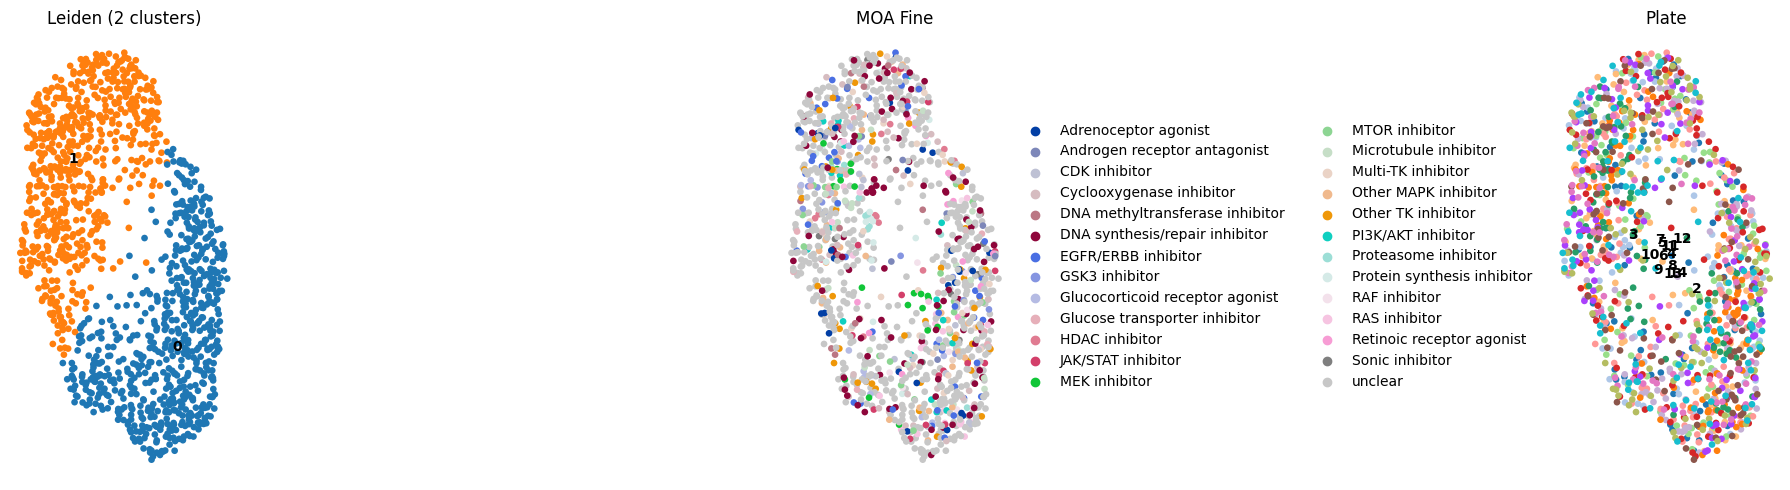

In [4]:
import os
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

save_dir_excel = '/home/ulc/co/mao/drug_clustering/TFM_mao/resultados'
save_dir = "/mnt/lustre/scratch/nlsas/home/ulc/co/mao/modelo_prueba_final_fast_convergence/leiden_results"

# Cargar ranking y coger el mejor
df_best = pd.read_excel(os.path.join(save_dir_excel, 'silhouette_ranking.xlsx'))

# Mostrar top 5
print(df_best.head(5).to_string())

# Cargar el mejor adata
best_file = df_best.iloc[0]['filename']
adata_best = sc.read_h5ad(os.path.join(save_dir, best_file + '.h5ad'))

leiden_key = [col for col in adata_best.obs.columns if 'leiden' in col][0]
n_clusters = adata_best.obs[leiden_key].nunique()

print(f"\nMejor configuración: {best_file} → {n_clusters} clusters")

# UMAP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc.pl.umap(adata_best, color=leiden_key,  title=f'Leiden ({n_clusters} clusters)',
           legend_loc='on data', frameon=False, ax=axes[0], show=False)
sc.pl.umap(adata_best, color='moa-fine', title='MOA Fine',
           legend_loc='right margin', frameon=False, ax=axes[1], show=False)
sc.pl.umap(adata_best, color='plate',     title='Plate',
           legend_loc='on data', frameon=False, ax=axes[2], show=False)

plt.tight_layout()
plt.show()


In [18]:
df_top_best = adata_best.obs['moa-fine'].value_counts().head(9)
df_top_best = df_top_best[1:9].index.tolist()

In [19]:
df_top_best

['DNA synthesis/repair inhibitor',
 'Other TK inhibitor',
 'EGFR/ERBB inhibitor',
 'Cyclooxygenase inhibitor',
 'Other MAPK inhibitor',
 'Multi-TK inhibitor',
 'Adrenoceptor agonist',
 'RAS inhibitor']

/mnt/netapp2/Store_uni/home/ulc/co/mao/SOFTWARE/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/plotting/_utils.py:431: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/mnt/netapp2/Store_uni/home/ulc/co/mao/SOFTWARE/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/netapp2/Store_uni/home/ulc/co/mao/SOFTWARE/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


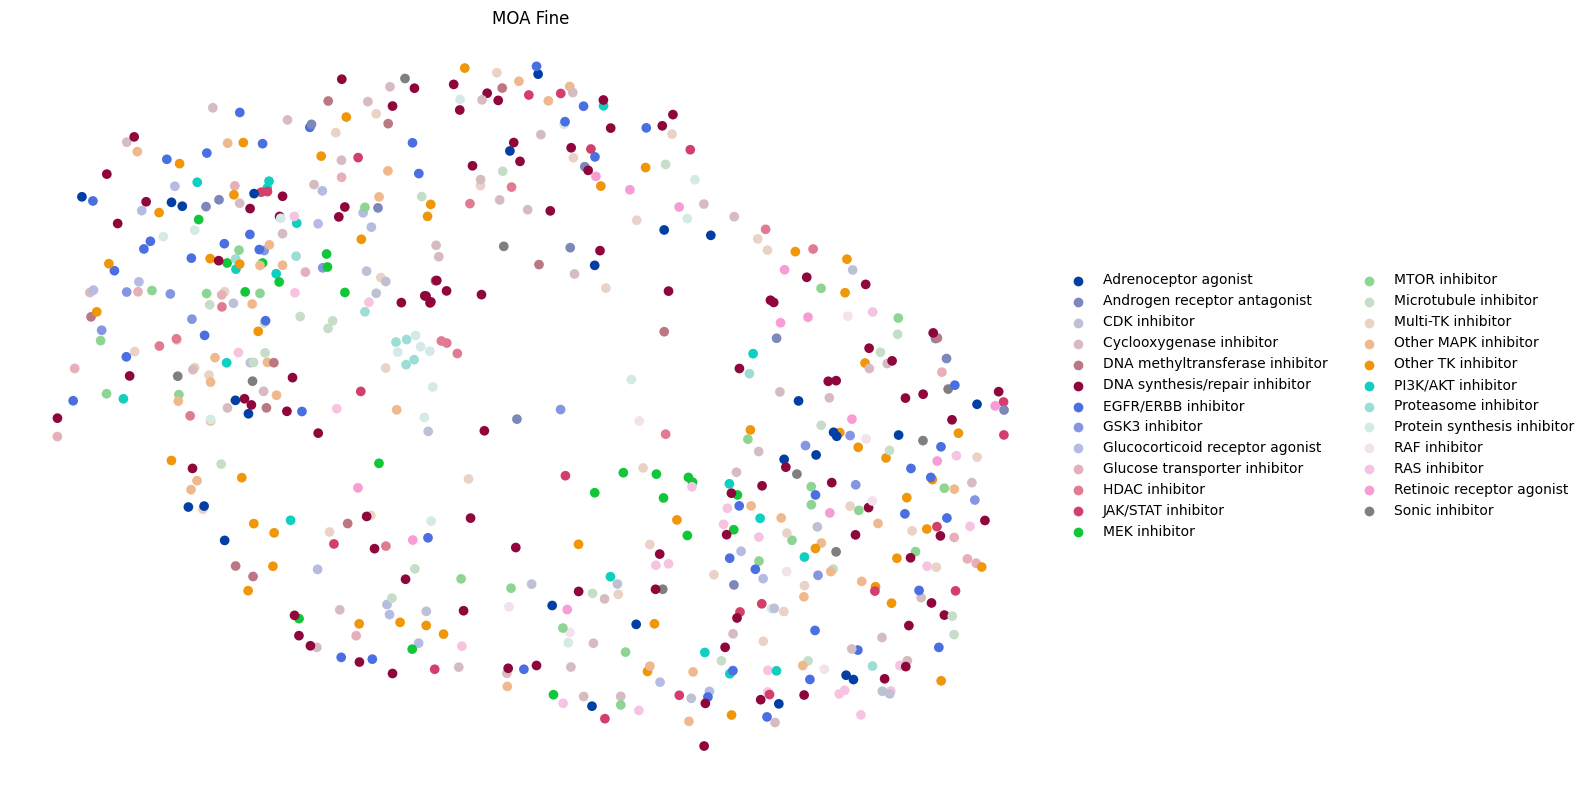

In [45]:
from matplotlib.pyplot import subplots
# 1. Los 8 moa-fine más frecuentes, quitando 'unclear'
moa_sin_unclear = (adata_best.obs['moa-fine']
                       .value_counts()
                       .drop('unclear', errors='ignore')
                       .index.tolist())

# 2. Crear columna: solo top 8, el resto NaN (gris)
adata_best.obs['moa_sin_unclear'] = adata_best.obs['moa-fine'].where(
    adata_best.obs['moa-fine'].isin(moa_sin_unclear), other=None).astype('category')
adata_best.obs['moa_sin_unclear'] = adata_best.obs['moa_sin_unclear'].cat.remove_unused_categories()

# 3. Dibujar
fig, ax = subplots(figsize=(16,8))
sc.pl.umap(adata_best[adata_best.obs['moa_sin_unclear'].notna()], 
           color='moa_sin_unclear',
           title='MOA Fine',
           legend_loc='right margin',
           color_map = 'viridis',
           ax=ax,
           frameon=False,
           show=False
           )
plt.tight_layout()
plt.show()
